# 05 Result Analysis

Local notebook for post-training metrics/table/figure analysis.

In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
OUT = Path(r"C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1")
print('OUT:', OUT)

OUT: C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1


In [14]:
model_cmp = pd.read_csv(OUT / 'tables' / 'model_comparison_metrics.csv')
trade_stats = pd.read_csv(OUT / 'tables' / 'trade_statistics.csv')
wf = pd.read_csv(OUT / 'tables' / 'walk_forward_results.csv')

display(model_cmp.sort_values('sharpe_ratio', ascending=False))
display(trade_stats)
display(wf.head())

,model,total_return,sharpe_ratio,max_drawdown,profit_factor
0,lstm_dmn,0.143851,1.972769,-0.054818,1.035463
1,ema_cross_32_96,0.835964,1.825838,-0.168122,0.625182
2,macd_32_96,0.835964,1.825838,-0.168122,0.625182
3,decoder_transformer,0.242830,1.000099,-0.193573,1.011118
4,ema_cross_8_24,0.146935,0.562188,-0.366673,0.229919
5,macd_8_24,0.146935,0.562188,-0.366673,0.229919
6,decoder_tft,0.036366,0.270704,-0.367077,0.996243
7,tsmom_78,-0.134437,-0.206628,-0.313299,0.256740
8,macd_16_48,-0.206370,-0.440085,-0.354431,0.377426
9,ema_cross_16_48,-0.206370,-0.440085,-0.354431,0.377426


,model,number_of_trades,turnover,average_net_pnl_points,percentage_time_long,percentage_time_short,percentage_time_flat
0,decoder_tft,54114,13484.498942,-0.001455,0.398993,0.382051,0.218956
1,decoder_transformer,53565,10599.418040,0.004326,0.402478,0.399326,0.198196
2,ema_cross_16_48,4450,4450.000000,-0.002217,0.499491,0.436544,0.063964
3,ema_cross_32_96,3372,3372.000000,0.017016,0.533208,0.415901,0.050891
4,ema_cross_8_24,6438,6438.000000,0.006453,0.476647,0.438912,0.084441
5,long_only,2400,2400.000000,-0.011702,0.959647,0.000000,0.040353
6,lstm_dmn,31380,4086.144752,0.002725,0.183689,0.274249,0.542062
7,macd_16_48,4450,4450.000000,-0.002217,0.499491,0.436544,0.063964
8,macd_32_96,3372,3372.000000,0.017016,0.533208,0.415901,0.050891
9,macd_8_24,6438,6438.000000,0.006453,0.476647,0.438912,0.084441


,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,hit_rate,profit_factor,average_trade_pnl,average_win,average_loss,win_loss_ratio,number_of_trades,turnover,window,model
0,-0.115163,-0.665261,0.367420,-2.978595,-3.455043,-0.152689,-4.356981,0.465105,0.749259,-0.169051,2.068722,-0.892023,2.319135,258,258.0,wf_1_2021-07-01_2021-12-31,long_only
1,-0.009762,-0.031482,0.350046,-0.091381,-0.130376,-0.093121,-0.338071,0.391284,0.146059,-0.762308,1.437146,-0.981765,1.463838,1488,1488.0,wf_1_2021-07-01_2021-12-31,tsmom_12
2,-0.003161,0.034728,0.358595,0.095202,0.134400,-0.136577,0.254277,0.404467,0.161775,-0.738012,1.426760,-0.978090,1.458721,1182,1182.0,wf_1_2021-07-01_2021-12-31,tsmom_24
3,0.037413,0.510514,0.356951,1.155485,1.605093,-0.062850,8.122695,0.428970,0.254942,-0.695846,1.951411,-1.063742,1.834477,754,754.0,wf_1_2021-07-01_2021-12-31,tsmom_48
4,-0.011924,-0.046889,0.363262,-0.132201,-0.180463,-0.086116,-0.544487,0.444169,0.266601,-0.638351,1.788608,-1.000159,1.788324,686,686.0,wf_1_2021-07-01_2021-12-31,tsmom_78


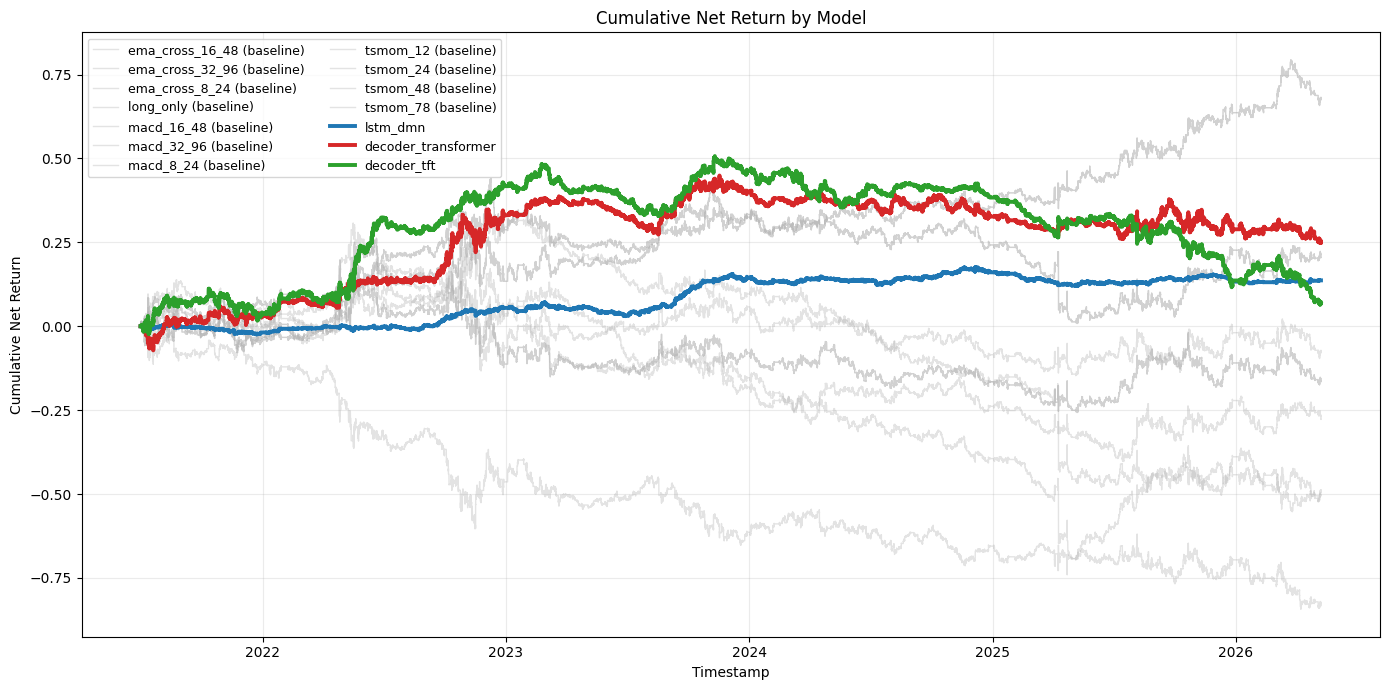

In [15]:
pred = pd.read_csv(OUT / 'predictions' / 'all_predictions.csv', parse_dates=['timestamp'])
pred = pred.sort_values(['model', 'timestamp'])
pred['cum_net_return'] = pred.groupby('model')['net_return'].cumsum()

focus_models = ['lstm_dmn', 'decoder_transformer', 'decoder_tft']
focus_colors = {
    'lstm_dmn': '#1f77b4',            # blue
    'decoder_transformer': '#d62728', # red
    'decoder_tft': '#2ca02c',         # green
}

plt.figure(figsize=(14, 7))

# plot non-focus first (background)
for model_name, g in pred.groupby('model'):
    if model_name in focus_models:
        continue
    plt.plot(
        g['timestamp'], g['cum_net_return'],
        color='#B0B0B0', linewidth=1.0, alpha=0.35,
        label=f'{model_name} (baseline)'
    )

# plot focus on top
for model_name in focus_models:
    g = pred[pred['model'] == model_name]
    if g.empty:
        continue
    plt.plot(
        g['timestamp'], g['cum_net_return'],
        color=focus_colors.get(model_name, None),
        linewidth=2.8, alpha=1.0,
        label=model_name
    )

plt.title('Cumulative Net Return by Model')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net Return')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

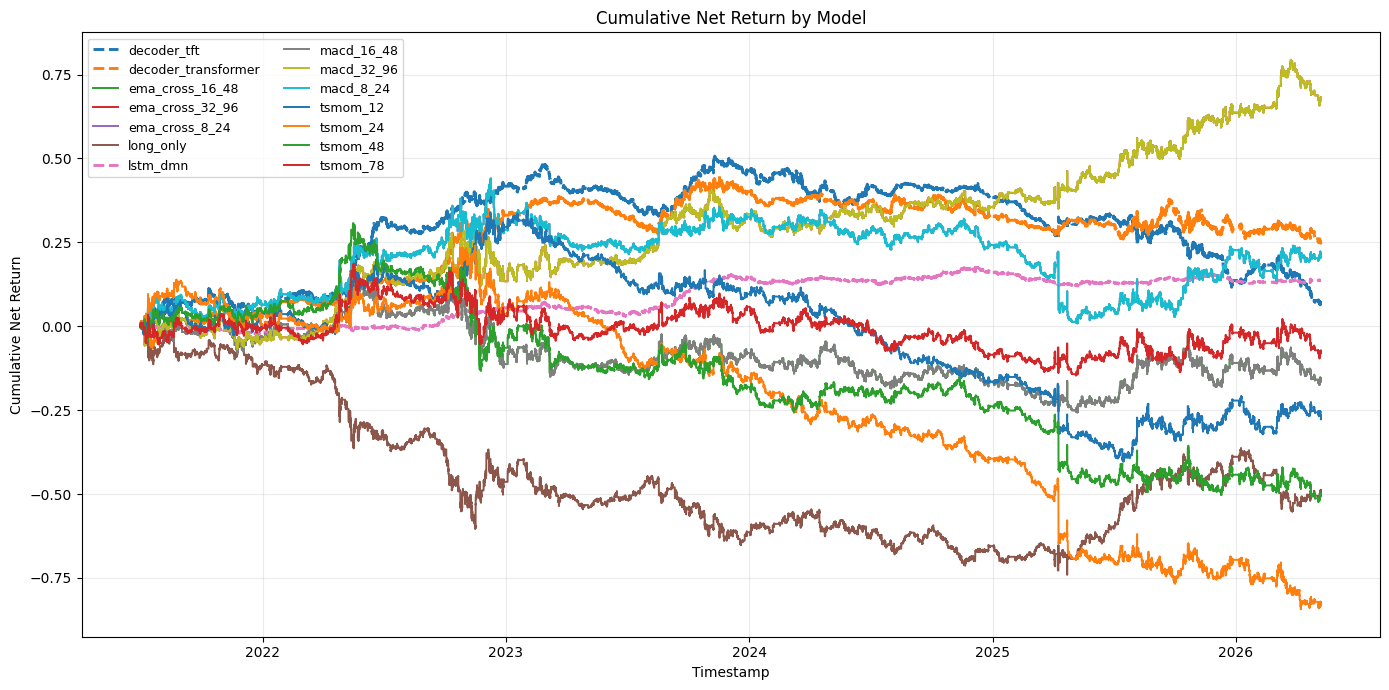

In [16]:
pred = pd.read_csv(OUT / 'predictions' / 'all_predictions.csv', parse_dates=['timestamp'])
pred = pred.sort_values(['model', 'timestamp'])
pred['cum_net_return'] = pred.groupby('model')['net_return'].cumsum()

focus_models = {'lstm_dmn', 'decoder_transformer', 'decoder_tft'}

plt.figure(figsize=(14, 7))
for model_name, g in pred.groupby('model'):
    ls = '--' if model_name in focus_models else '-'
    lw = 2.1 if model_name in focus_models else 1.4
    plt.plot(g['timestamp'], g['cum_net_return'], label=model_name, linewidth=lw, linestyle=ls)
plt.title('Cumulative Net Return by Model')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net Return')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

,days,mean_daily_cost,median_daily_cost,p95_daily_cost,max_daily_cost,total_cost
model,,,,,,
decoder_tft,1200,191524.150253,173307.829586,434721.697798,608853.509916,2.298290e+08
tsmom_12,1200,190004.915157,186242.386000,315197.939800,444303.104000,2.280059e+08
decoder_transformer,1200,146985.262838,136963.170608,273947.679741,466856.376110,1.763823e+08
tsmom_24,1200,145409.802720,133537.672000,288771.716400,473358.612000,1.744918e+08
tsmom_48,1200,93834.007730,66363.200000,242856.795800,501486.856000,1.126008e+08
ema_cross_8_24,1200,89967.157790,79092.224000,169831.211600,279350.848000,1.079606e+08
macd_8_24,1200,89967.157790,79092.224000,169831.211600,279350.848000,1.079606e+08
tsmom_78,1200,81391.620650,62315.618000,209200.470000,374137.808000,9.766994e+07
ema_cross_16_48,1200,62139.196417,61216.058000,134004.892600,231130.060000,7.456704e+07


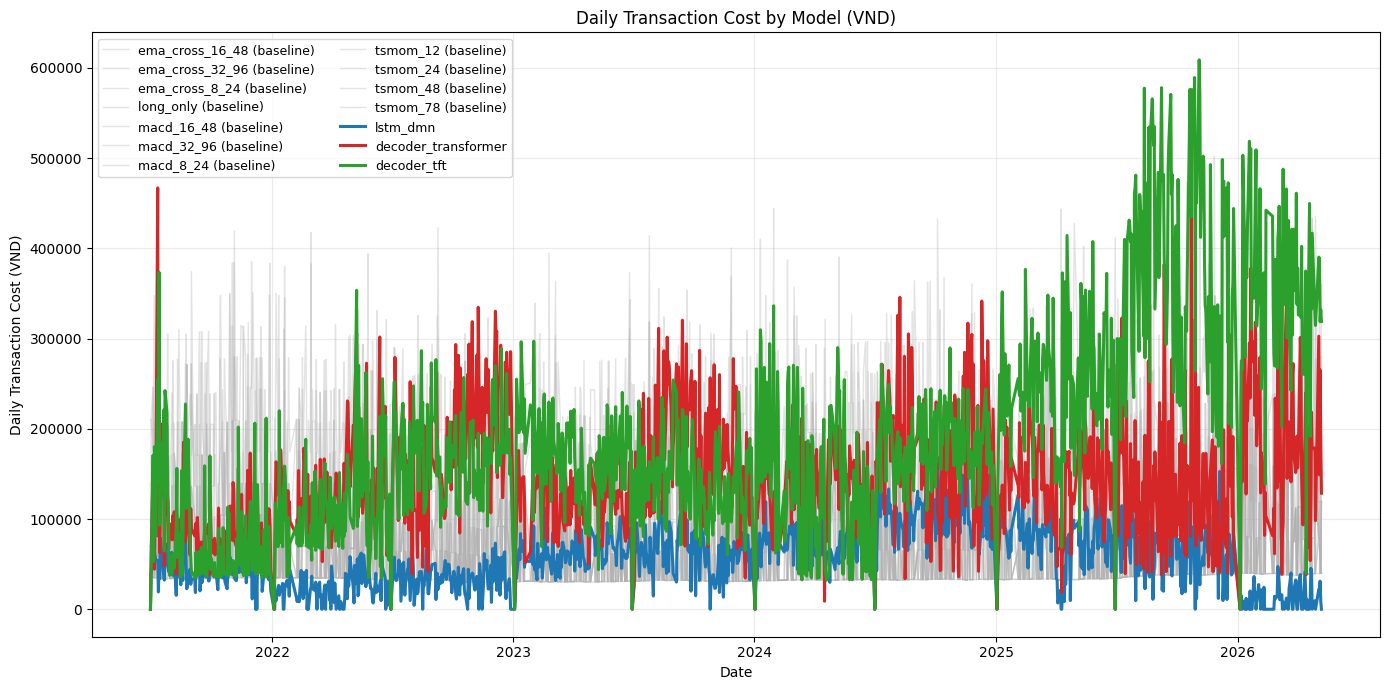

In [17]:
import numpy as np
from pathlib import Path

if 'PROJ' not in globals():
    if 'OUT' in globals():
        PROJ = OUT.parents[1]
    else:
        PROJ = Path.cwd().resolve().parent

px = pd.read_parquet(PROJ / 'data' / 'features' / 'features_5min.parquet')[['timestamp', 'close']]
cost_df = pred[['timestamp', 'model', 'position']].merge(px, on='timestamp', how='left')
cost_df = cost_df.sort_values(['model', 'timestamp']).copy()

contract_multiplier = 100000
margin_rate = 0.1848
transfer_tax_rate = 0.001
fixed_fee_per_side = 5000 + 2700 + 2700

cost_df['prev_pos'] = cost_df.groupby('model')['position'].shift(1).fillna(0.0)
cost_df['buy_units'] = (cost_df['position'] - cost_df['prev_pos']).clip(lower=0.0)
cost_df['sell_units'] = (cost_df['prev_pos'] - cost_df['position']).clip(lower=0.0)

cost_df['tax_vnd_per_contract'] = (
    margin_rate * contract_multiplier * transfer_tax_rate * cost_df['close'] / 2.0
)
cost_df['buy_cost_vnd'] = cost_df['buy_units'] * fixed_fee_per_side
cost_df['sell_fixed_cost_vnd'] = cost_df['sell_units'] * fixed_fee_per_side
cost_df['sell_tax_cost_vnd'] = cost_df['sell_units'] * cost_df['tax_vnd_per_contract']
cost_df['tx_cost_vnd'] = cost_df['buy_cost_vnd'] + cost_df['sell_fixed_cost_vnd'] + cost_df['sell_tax_cost_vnd']
cost_df['date'] = cost_df['timestamp'].dt.date

daily_cost = cost_df.groupby(['model', 'date'], as_index=False)['tx_cost_vnd'].sum()
daily_cost_stats = (
    daily_cost.groupby('model')['tx_cost_vnd']
    .agg(
        days='count',
        mean_daily_cost='mean',
        median_daily_cost='median',
        p95_daily_cost=lambda s: s.quantile(0.95),
        max_daily_cost='max',
        total_cost='sum',
    )
    .sort_values('total_cost', ascending=False)
)

display(daily_cost_stats)

focus_models = ['lstm_dmn', 'decoder_transformer', 'decoder_tft']
focus_colors = {
    'lstm_dmn': '#1f77b4',
    'decoder_transformer': '#d62728',
    'decoder_tft': '#2ca02c',
}

daily_cost = daily_cost.sort_values(['model', 'date'])
daily_cost['date'] = pd.to_datetime(daily_cost['date'])

plt.figure(figsize=(14, 7))
for model_name, g in daily_cost.groupby('model'):
    if model_name in focus_models:
        continue
    plt.plot(
        g['date'], g['tx_cost_vnd'],
        color='#B0B0B0', linewidth=1.0, alpha=0.35,
        label=f'{model_name} (baseline)'
    )

for model_name in focus_models:
    g = daily_cost[daily_cost['model'] == model_name]
    if g.empty:
        continue
    plt.plot(
        g['date'], g['tx_cost_vnd'],
        color=focus_colors.get(model_name, None),
        linewidth=2.2, alpha=1.0,
        label=model_name
    )

plt.title('Daily Transaction Cost by Model (VND)')
plt.xlabel('Date')
plt.ylabel('Daily Transaction Cost (VND)')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


In [18]:
fig_path = OUT / 'figures' / 'model_cumulative_returns.png'
print('Saved figure exists:', fig_path.exists(), fig_path)

Saved figure exists: True C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1\figures\model_cumulative_returns.png
